<a href="https://colab.research.google.com/github/saverin0/Change-Detection-Using-Dinov3/blob/main/03_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SpaceNet-7 Temporal Change Detection with DINOv3
## Part 3: Training the Temporal Change Detector

### What this notebook does
It trains a model that looks at **all monthly DINOv3 features of a location at once** and predicts two things at 128×128 resolution:

| Output | Shape per location | Question it answers |
|---|---|---|
| **Pixel change** (main task) | `(T-1, 128, 128)` | Did buildings appear or disappear here between month t and the next available month? |
| **Building mask** (auxiliary task) | `(T, 128, 128)` | Is there a building here in month t? |

The building task gives the model extra supervision on every frame. That helps with the main change task, where positives are rare.

> **Cloud-masked pixels are ignored.** SpaceNet-7 leaves buildings under cloud-masked areas out of that month's labels. Those buildings then look like they vanish and reappear, and ~88% of the raw change labels are this artifact. Using the mask maps from Part 1 (Step 13), every pixel that is masked in a frame is **excluded from the loss and from every metric**. The model is trained and scored only on what it can actually see.

### Inputs (from Parts 1 and 2)
| From | File | Used for |
|---|---|---|
| Part 1 | `labels/<loc_id>_labels.npz` | `building_masks`, `pixel_change_masks`, `months` (targets) |
| Part 2 | `<FEATURES_SUBDIR>/<loc_id>_features.npz` | `features` `(T, G, G, D)` float16 (inputs): `(T, 64, 64, 256)` for the default `features_1024_pca256` |
| Part 1, Step 13 | `masks/<loc_id>_masks.npz` | `masked` `(T, 128, 128)`: which pixels to ignore |
| Part 1, Step 14 | `training/split.json` | Train / validation / test locations |

### Pipeline at a glance
```
Mount Drive ─► Install deps ─► Load config & settings ─► Check GPU
     ─► Load features + labels + masks into RAM ─► Load split ─► Batching & augmentation
     ─► Define model ─► Loss & metrics ─► Memory check ─► Train (resumable, early stopping)
     ─► Training curves ─► Test-set evaluation ─► Prediction visuals
```

### Before you run
1. **Run Part 1 (including Steps 13–14: cloud masks and split) and Part 2 first.**
2. **GPU runtime:** Runtime → Change runtime type → **T4 GPU**.
3. **RAM:** all features (~3 GB) are loaded into memory. The standard Colab runtime (~12 GB) is enough.

### Runs
Each training run writes to its own folder, **`training/<RUN_NAME>/`** on Drive (checkpoints, history, metrics, figures), so runs never overwrite or accidentally resume each other. To compare feature resolutions, run this notebook twice, changing only these two settings in Step 3:

| Run | `FEATURES_SUBDIR` | `MODEL_VARIANT` | `LOSS_REGION` | `RUN_NAME` |
|---|---|---|---|---|
| 32×32 patches (~150 m) | `features` | `baseline` | `dice` | `grid32` |
| **64×64 patches (~75 m), default** | `features_1024_pca256` | `baseline` | `dice` | `grid64_pca256` |
| Spatial cross-attention + Tversky loss | `features_1024_pca256` | `xattn` | `tversky` | `grid64_xattn_tversky` |

## Step 1: Mount Google Drive

Features, labels, and the raw images used for the final figures all live on Drive. Checkpoints are saved there too, so training survives a disconnect.

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Install dependencies and import libraries

Colab already has PyTorch, NumPy, and Matplotlib. **rasterio** is needed only for the prediction figures (Step 14), to read the satellite images, and is installed if missing.

In [2]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("rasterio") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rasterio"])

import json
import math
import random
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from rasterio.enums import Resampling
from torch.utils.checkpoint import checkpoint
from tqdm.auto import tqdm

print(f"torch {torch.__version__}")

torch 2.11.0+cu128


## Step 3: Load the configuration and set training options

Paths and shared settings come from Part 1's `config.json`. Training options are set here:

| Setting | Value | Why |
|---|---|---|
| `FEATURES_SUBDIR` | `features_1024_pca256` | Part 2 output folder to train on. `features` is the original 32×32 run |
| `RUN_NAME` | `grid64_pca256` | Outputs go to `training/<RUN_NAME>/`. Use a new name for every experiment |
| `MODEL_VARIANT` | `baseline` | `baseline`: pair features `[x_t, x_t+1, x_t+1 − x_t]`. `xattn`: adds **spatial cross-attention**, where every patch of month t+1 looks at all patches of month t before the difference is taken (Step 8) |
| `LOSS_REGION` | `dice` | Region term of the loss. `dice` treats false alarms and misses equally; `tversky` weights misses more (β = 0.7), pushing the model toward recall (Step 9) |
| `TRANSFORMER_DIM` / `N_HEADS` / `N_LAYERS` | 256 / 8 / 4 | Small temporal transformer. With ~60 locations, a larger model would mostly memorize |
| `DROPOUT` | 0.2 | Up from 0.1 in the first run, which overfit after ~20 epochs |
| `MAX_MONTH_SPAN` | 36 | Size of the time embedding, indexed by **calendar month offset**. Locations span at most 27 months |
| `BATCH_SIZE` × `GRAD_ACCUM_STEPS` | 2 × 2 | 2 locations per forward pass, with gradients summed over 2 passes: an **effective batch of 4**. A 64×64 grid has 4× the patches of 32×32. Step 10 reports actual GPU memory |
| `EPOCHS` | from config (50) | Maximum; early stopping usually ends sooner |
| `EARLY_STOP_PATIENCE` | 10 | Stop when validation F1 hasn't improved for 10 epochs |
| `LEARNING_RATE` | 3e-4 | AdamW with a 2-epoch linear warmup, then cosine decay to 1% |
| `WEIGHT_DECAY` | 0.05 | Up from 0.01, stronger regularization against overfitting |
| `BUILDING_LOSS_WEIGHT` | 0.5 | The building task helps, but change detection is the main objective |
| `SAVE_EVERY` | 5 | Epochs between resume checkpoints on Drive |
| `RESUME` | True | Continue from `training/<RUN_NAME>/last.pt` if it exists |

In [3]:
# Must match cache_base from Part 1.
CACHE_BASE = Path("/content/drive/MyDrive/datasets/spacenet7_cache")

config_path = CACHE_BASE / "config.json"
if not config_path.exists():
    raise FileNotFoundError(f"{config_path} not found. Run Parts 1 and 2 first, with the same cache_base.")
config = json.loads(config_path.read_text())

# Which Part 2 features to train on, and where this run's outputs go.
# Original 32x32 run: FEATURES_SUBDIR = "features", RUN_NAME = "grid32"
FEATURES_SUBDIR = "features_1024_pca256"
RUN_NAME = "grid64_pca256"
MODEL_VARIANT = "baseline"   # "baseline" or "xattn"
LOSS_REGION = "dice"         # "dice" or "tversky"

DATA_ROOT = Path(config["data_root"])
CACHE_DIR = Path(config["cache_dir"])
LABELS_DIR = CACHE_DIR / "labels"
FEATURES_DIR = CACHE_DIR / FEATURES_SUBDIR
MASKS_DIR = CACHE_DIR / "masks"
SPLIT_PATH = CACHE_DIR / "training" / "split.json"
TRAINING_DIR = CACHE_DIR / "training"
OUTPUT_DIR = TRAINING_DIR / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_RES = config["output_resolution"]
if MODEL_VARIANT not in ("baseline", "xattn"):
    raise ValueError(f"MODEL_VARIANT must be 'baseline' or 'xattn', not {MODEL_VARIANT!r}")
if LOSS_REGION not in ("dice", "tversky"):
    raise ValueError(f"LOSS_REGION must be 'dice' or 'tversky', not {LOSS_REGION!r}")

# Model
TRANSFORMER_DIM = 256
N_HEADS = 8
N_LAYERS = 4
DROPOUT = 0.2
MAX_MONTH_SPAN = 36

# Training
EPOCHS = config["epochs"]
BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 2
EARLY_STOP_PATIENCE = 10
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 2
BUILDING_LOSS_WEIGHT = 0.5
SEED = 42
SAVE_EVERY = 5
RESUME = True

print("Configuration:")
print(f"   Features: {FEATURES_DIR}")
print(f"   Labels: {LABELS_DIR}")
print(f"   Outputs: {OUTPUT_DIR}")
print(f"   Output resolution: {OUTPUT_RES}x{OUTPUT_RES}")
print(f"   Run: {RUN_NAME} | model: {MODEL_VARIANT} | loss region: {LOSS_REGION}")
print(f"   Max epochs: {EPOCHS} (early stop after {EARLY_STOP_PATIENCE} without improvement)")
print(f"   Batch: {BATCH_SIZE} x {GRAD_ACCUM_STEPS} accumulation = {BATCH_SIZE * GRAD_ACCUM_STEPS} | LR: {LEARNING_RATE} | "
      f"weight decay: {WEIGHT_DECAY} | dropout: {DROPOUT}")

Configuration:
   Features: /content/drive/MyDrive/datasets/spacenet7_cache/features_1024_pca256
   Labels: /content/drive/MyDrive/datasets/spacenet7_cache/labels
   Outputs: /content/drive/MyDrive/datasets/spacenet7_cache/training/grid64_pca256
   Output resolution: 128x128
   Run: grid64_pca256 | model: baseline | loss region: dice
   Max epochs: 50 (early stop after 10 without improvement)
   Batch: 2 x 2 accumulation = 4 | LR: 0.0003 | weight decay: 0.05 | dropout: 0.2


## Step 4: Check the GPU and fix random seeds

Training needs a GPU, so the cell stops if none is attached. Seeds are fixed so the train/val/test split and weight initialization are the same every run.

In [4]:
if not torch.cuda.is_available():
    raise RuntimeError("No GPU found. In Colab: Runtime -> Change runtime type -> T4 GPU, then run all cells again.")

device = torch.device("cuda")
print(f"GPU: {torch.cuda.get_device_name()} ({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

GPU: Tesla T4 (15.6 GB)


## Step 5: Load features and labels into RAM

Every location is loaded once, up front. Training then reads from memory and never waits on Drive. The files are few and large (~50 MB each), so reading them straight from Drive with **6 parallel threads** is fast. There's no need to copy them to local disk first, as Parts 1 and 2 did with thousands of small files.

For each location:
1. **Features:** kept as float16 `(T, G, G, D)` from `FEATURES_SUBDIR`, ~50 MB each and ~3 GB for all 60, for both `features` (32×32×1024) and `features_1024_pca256` (64×64×256). The grid size `G` and feature size `D` are read from the files.
2. **Targets:** the full-resolution masks (~1024 px) are shrunk to 128×128 with **max-pooling**. An output cell is positive if *any* pixel inside it is positive, so small buildings and thin change regions survive. Plain resizing would blur most of them away. The results are stored as `uint8`, ~0.6 MB per location.
3. **Month offsets:** each month becomes "months since this location's first image" (e.g. `2018_01, 2018_02, 2018_05` → `0, 1, 4`). 34 of the 60 locations skip some calendar months, and the offsets tell the model how much time really passed between frames.
4. **Cloud masks:** `masked` `(T, 128, 128)` from Part 1 Step 13. From it:
   - a **building** target pixel is ignored if it's masked in that month
   - a **change** target pixel is ignored if it's masked in **either** month of the pair
5. **Alignment check:** feature, label, and mask `months` must all match, or loading stops with an error.

In [5]:
def month_index(month):
    year, mon = map(int, str(month).split("_"))
    return year * 12 + mon - 1


def max_pool_masks(masks, size):
    pooled = F.adaptive_max_pool2d(torch.from_numpy(masks).float().unsqueeze(1), size)
    return pooled.squeeze(1).to(torch.uint8)


def load_location(loc_id):
    with np.load(FEATURES_DIR / f"{loc_id}_features.npz") as f:
        features = torch.from_numpy(f["features"])
        feature_months = [str(m) for m in f["months"]]
    with np.load(LABELS_DIR / f"{loc_id}_labels.npz", allow_pickle=True) as labels:
        months = [str(m) for m in labels["months"]]
        building = max_pool_masks(labels["building_masks"], OUTPUT_RES)
        change = max_pool_masks(labels["pixel_change_masks"], OUTPUT_RES)
    with np.load(MASKS_DIR / f"{loc_id}_masks.npz") as m:
        masked = torch.from_numpy(m["masked"])
        mask_months = [str(month) for month in m["months"]]
    if feature_months != months:
        raise ValueError(f"{loc_id}: feature months do not match label months")
    if mask_months != months:
        raise ValueError(f"{loc_id}: mask months do not match label months. Re-run Part 1 Step 13.")

    offsets = torch.tensor([month_index(m) for m in months])
    return {
        "features": features,
        "building": building,
        "change": change,
        "masked": masked,
        "month_offsets": offsets - offsets[0],
        "months": months,
    }


feature_ids = {p.name.removesuffix("_features.npz") for p in FEATURES_DIR.glob("*_features.npz")}
label_ids = {p.name.removesuffix("_labels.npz") for p in LABELS_DIR.glob("*_labels.npz")}
mask_ids = {p.name.removesuffix("_masks.npz") for p in MASKS_DIR.glob("*_masks.npz")}
if label_ids - mask_ids:
    raise FileNotFoundError(
        f"{len(label_ids - mask_ids)} locations have no cloud-mask file in {MASKS_DIR}. "
        "Run Part 1 (Step 13) first."
    )
location_ids = sorted(feature_ids & label_ids)
if not location_ids:
    raise FileNotFoundError(f"No locations have both features in {FEATURES_DIR} and labels. Run Parts 1 and 2 first.")
if feature_ids != label_ids:
    print(f"Warning: using {len(location_ids)} locations with both files "
          f"({len(label_ids - feature_ids)} missing features, {len(feature_ids - label_ids)} missing labels)")

with ThreadPoolExecutor(max_workers=6) as pool:
    data = dict(zip(location_ids, tqdm(pool.map(load_location, location_ids), total=len(location_ids), desc="Loading")))

T_MAX = max(len(d["months"]) for d in data.values())
GRID = next(iter(data.values()))["features"].shape[1]
longest_span = max(int(d["month_offsets"][-1]) for d in data.values()) + 1
if longest_span > MAX_MONTH_SPAN:
    raise ValueError(f"A location spans {longest_span} months; raise MAX_MONTH_SPAN.")

FEATURE_DIM = next(iter(data.values()))["features"].shape[-1]
ram_gb = sum(d["features"].nbytes + d["building"].nbytes + d["change"].nbytes + d["masked"].nbytes
             for d in data.values()) / 1e9
print(f"Loaded {len(data)} locations ({ram_gb:.1f} GB in RAM)")
print(f"   Months per location: {min(len(d['months']) for d in data.values())}-{T_MAX} | Longest span: {longest_span} months")
print(f"   Features: {GRID}x{GRID} x {FEATURE_DIM} from {FEATURES_SUBDIR} -> targets {OUTPUT_RES}x{OUTPUT_RES}")

Loading:   0%|          | 0/60 [00:00<?, ?it/s]

Loaded 60 locations (3.1 GB in RAM)
   Months per location: 18-26 | Longest span: 27 months
   Features: 64x64 x 256 from features_1024_pca256 -> targets 128x128


## Step 6: Load the train / validation / test split

The split is created **once, in Part 1 (Step 14)**, and read from `training/split.json`. Part 2 fits its PCA on the same training locations, and every training run here uses the same locations, so results are comparable. The split is **by location**, never by month. Months of the same place are strongly correlated, so mixing them across splits would leak answers and inflate scores.

| Split | Locations | Used for |
|---|---|---|
| **Train** | ~70% (42) | Updating the model |
| **Validation** | ~15% (9) | Picking the best epoch and the best decision threshold |
| **Test** | ~15% (9) | **Final, untouched evaluation**, run once in Step 13 |

Validation is used to choose the checkpoint and threshold, so its scores are slightly optimistic. **Report the test scores.**

This cell also prints, per split:
- **ignored change pixels:** the share of change-target pixels excluded because they're masked in either month
- **change label removed:** the share of raw change-label pixels that fell inside masked areas (~88% overall)
- **change / building pixels:** the share of *kept* pixels that are positive

Real change is rare: expect well under 1% positive.

In [6]:
if not SPLIT_PATH.exists():
    raise FileNotFoundError(f"{SPLIT_PATH} not found. Run Part 1 (Step 14) to create the split.")
split = json.loads(SPLIT_PATH.read_text())
if set(sum(split.values(), [])) != set(location_ids):
    raise ValueError(f"{SPLIT_PATH} lists different locations than are loaded (missing features or labels?).")
print(f"Split from {SPLIT_PATH}")

def kept_masks(d):
    return ~(d["masked"][:-1] | d["masked"][1:]), ~d["masked"]


for name, ids in split.items():
    raw_change = kept_change = change_cells = kept_change_cells = 0
    kept_building = building_cells = 0
    for i in ids:
        d = data[i]
        change_keep, building_keep = kept_masks(d)
        change = d["change"].bool()
        raw_change += int(change.sum())
        kept_change += int((change & change_keep).sum())
        change_cells += change.numel()
        kept_change_cells += int(change_keep.sum())
        kept_building += int((d["building"].bool() & building_keep).sum())
        building_cells += int(building_keep.sum())
    print(f"   {name:5s}: {len(ids):2d} locations | ignored change pixels {100 * (1 - kept_change_cells / change_cells):.1f}% | "
          f"change label removed {100 * (1 - kept_change / max(raw_change, 1)):.0f}% | "
          f"change pixels {100 * kept_change / kept_change_cells:.2f}% | building pixels {100 * kept_building / building_cells:.1f}%")

Split from /content/drive/MyDrive/datasets/spacenet7_cache/training/split.json
   train: 42 locations | ignored change pixels 7.1% | change label removed 84% | change pixels 0.31% | building pixels 28.0%
   val  :  9 locations | ignored change pixels 3.8% | change label removed 69% | change pixels 0.38% | building pixels 22.4%
   test :  9 locations | ignored change pixels 5.1% | change label removed 69% | change pixels 0.31% | building pixels 20.3%


## Step 7: Batching and augmentation

`make_batch` stacks several locations into padded tensors, because locations have different numbers of months (18–26):

| Tensor | Shape | Notes |
|---|---|---|
| `features` | `(B, T_MAX, G, G, D)` float16 | Padded frames are zeros. `(B, T_MAX, 64, 64, 256)` by default |
| `building` | `(B, T_MAX, 128, 128)` | |
| `change` | `(B, T_MAX-1, 128, 128)` | |
| `masked` | `(B, T_MAX, 128, 128)` bool | Cloud-masked pixels per month, from Part 1 |
| `month_offsets` | `(B, T_MAX)` | |
| `valid` | `(B, T_MAX)` bool | `True` for real months, `False` for padding |

`valid` is what lets the model and loss **ignore padding**. The old trainer computed the loss on padded frames too, which trained the model on fake "no buildings, no change" frames.

**Augmentation (training only):** each location gets a random 90° rotation (0/90/180/270) and a random horizontal flip. The *same* transform is applied to the 32×32 feature grid, the 128×128 targets, and the cloud masks. They stay aligned because 128 is an exact multiple of the grid (4 × 32, or 2 × 64). Satellite imagery has no fixed "up", so this gives 8 orientations of every location for free.

Features stay float16 on the GPU (~0.2 GB for a batch). The old trainer converted them to float32 first: 3.4 GB for a batch of 8.

In [7]:
def augment(features, *maps):
    k = random.randint(0, 3)
    flip = random.random() < 0.5
    out = []
    for tensor in (features, *maps):
        tensor = torch.rot90(tensor, k, dims=(1, 2))
        out.append(tensor.flip(2) if flip else tensor)
    return out


def make_batch(loc_ids, augment_data=False):
    B = len(loc_ids)
    features = torch.zeros(B, T_MAX, GRID, GRID, FEATURE_DIM, dtype=torch.float16)
    building = torch.zeros(B, T_MAX, OUTPUT_RES, OUTPUT_RES, dtype=torch.uint8)
    change = torch.zeros(B, T_MAX - 1, OUTPUT_RES, OUTPUT_RES, dtype=torch.uint8)
    masked = torch.ones(B, T_MAX, OUTPUT_RES, OUTPUT_RES, dtype=torch.bool)
    offsets = torch.zeros(B, T_MAX, dtype=torch.long)
    valid = torch.zeros(B, T_MAX, dtype=torch.bool)

    for i, loc_id in enumerate(loc_ids):
        d = data[loc_id]
        T = len(d["months"])
        f, b, c, m = d["features"], d["building"], d["change"], d["masked"]
        if augment_data:
            f, b, c, m = augment(f, b, c, m)
        features[i, :T] = f
        building[i, :T] = b
        change[i, :T - 1] = c
        masked[i, :T] = m
        offsets[i, :T] = d["month_offsets"]
        valid[i, :T] = True

    batch = {"features": features, "building": building, "change": change, "masked": masked,
             "month_offsets": offsets, "valid": valid}
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


def batches(loc_ids, batch_size, shuffle=False, augment_data=False):
    ids = list(loc_ids)
    if shuffle:
        random.shuffle(ids)
    for i in range(0, len(ids), batch_size):
        yield make_batch(ids[i:i + batch_size], augment_data)


sample = make_batch(split["train"][:2], augment_data=True)
print({k: (tuple(v.shape), str(v.dtype).replace("torch.", "")) for k, v in sample.items()})
del sample

{'features': ((2, 26, 64, 64, 256), 'float16'), 'building': ((2, 26, 128, 128), 'uint8'), 'change': ((2, 25, 128, 128), 'uint8'), 'masked': ((2, 26, 128, 128), 'bool'), 'month_offsets': ((2, 26), 'int64'), 'valid': ((2, 26), 'bool')}


## Step 8: Define the model

```
features (B, T, G, G, D)                             (G = 64, D = 256 by default)
   │  Linear D→256 + LayerNorm + GELU + Dropout      (per patch, per month)
   │  + time embedding[month offset]                 (real calendar gap)
   ▼
temporal Transformer (4 layers, 8 heads, pre-norm)   (each of the G×G patches attends across its own months;
   │                                                  padded months are masked out)
   ├──► building decoder on every valid month      ─► building logits (N_months, 128, 128)
   └──► pair features [x_t, x_t+1, x_t+1 − x_t]
            │ Linear 768→256 + GELU
            └──► change decoder on every valid pair ─► change logits (N_pairs, 128, 128)
```

**Decoder:** just enough up-sampling stages to reach 128: **one** for a 64×64 grid (64 → 128), two for 32×32. The last stage always outputs **64 channels**, so the work at full 128×128 resolution (a 3×3 conv for spatial context, then a 1×1 output conv) costs the same for every grid size. That 3×3 conv is the most expensive op in training; at 128 channels it would be 4× slower. Each stage is a transposed conv + GroupNorm + GELU. Compared with the old trainer:
- **Fewer stages.** The old decoder was built for a 14×14 grid. On 32×32 it went up to 256 px and was then shrunk back to 128, wasting memory and compute.
- **GroupNorm instead of BatchNorm.** Batches are small and contain a variable number of frames, which makes BatchNorm statistics noisy.
- **Only real frames are decoded** (`x[valid]`), so padding costs no decoder compute and never reaches the loss.

**Change input:** each consecutive pair gives the change decoder `[x_t, x_{t+1}, x_{t+1} − x_t]`. The explicit difference term makes "what's different" directly visible.

**`MODEL_VARIANT = "xattn"`: spatial cross-attention.** In the baseline, a patch is only ever compared with the *same* patch of the previous month. With `xattn`, before the difference is taken, every patch of month t+1 attends to **all patches of month t** (8 heads, fixed 2-D sine/cosine position encodings so it can prefer nearby patches). The result is a version of month t "as seen from" month t+1, which absorbs small misalignments between mosaics and gives each comparison spatial context. This is the idea behind the `CrossAttentionHead` in the old pairwise experiments, applied here on top of the temporal transformer. It runs with PyTorch's memory-efficient attention (`scaled_dot_product_attention`), so the 4,096×4,096 attention matrix per pair is never materialized. Cost on a T4: roughly +20% per epoch.

**Memory:** during training, **gradient checkpointing** stores only the inputs of the input projection, each transformer layer, and both decoders, and recomputes the rest in the backward pass. This costs ~30% more compute but is what lets a 64×64 grid fit on a T4. The biggest activations are the decoders' 128×128 maps for ~50 frames. The old trainer checkpointed the whole encoder as one block, which doesn't lower peak memory: its backward pass recomputes all layers at once.

In [8]:
class Decoder(nn.Module):
    def __init__(self, in_channels, grid, output_res):
        super().__init__()
        n_stages = int(math.log2(output_res // grid))
        if grid * 2 ** n_stages != output_res:
            raise ValueError(f"output_res {output_res} must be grid {grid} times a power of 2")

        layers, channels = [], in_channels
        for stage in range(n_stages):
            out_channels = 64 if stage == n_stages - 1 else max(64, channels // 2)
            layers += [nn.ConvTranspose2d(channels, out_channels, 4, stride=2, padding=1),
                       nn.GroupNorm(8, out_channels), nn.GELU()]
            channels = out_channels
        layers += [nn.Conv2d(channels, channels, 3, padding=1), nn.GroupNorm(8, channels), nn.GELU(),
                   nn.Conv2d(channels, 1, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


def sincos_position_encoding(grid, dim):
    """Fixed 2-D sine/cosine position encoding, (grid*grid, dim)."""
    quarter = dim // 4
    omega = 1.0 / (10000 ** (torch.arange(quarter, dtype=torch.float32) / quarter))
    ys, xs = torch.meshgrid(torch.arange(grid, dtype=torch.float32), torch.arange(grid, dtype=torch.float32), indexing="ij")
    out = []
    for coord in (ys.flatten(), xs.flatten()):
        angles = coord[:, None] * omega[None, :]
        out += [torch.sin(angles), torch.cos(angles)]
    return torch.cat(out, dim=1)


class SpatialCrossAttention(nn.Module):
    """Every patch of month t+1 attends to all patches of month t; returns month t aligned to t+1."""

    def __init__(self, dim, n_heads, grid, dropout):
        super().__init__()
        self.n_heads, self.dropout = n_heads, dropout
        self.register_buffer("pos", sincos_position_encoding(grid, dim), persistent=False)
        self.norm_next, self.norm_prev = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.to_q, self.to_kv, self.out = nn.Linear(dim, dim), nn.Linear(dim, 2 * dim), nn.Linear(dim, dim)

    def forward(self, x_prev, x_next, pairs_per_chunk=4):
        P, D, H, W = x_prev.shape
        prev = x_prev.flatten(2).transpose(1, 2)
        nxt = x_next.flatten(2).transpose(1, 2)
        q = self.to_q(self.norm_next(nxt) + self.pos)
        k, v = self.to_kv(self.norm_prev(prev) + self.pos).chunk(2, dim=-1)
        heads = lambda t: t.reshape(len(t), H * W, self.n_heads, D // self.n_heads).transpose(1, 2)
        # A few pairs at a time keeps peak memory bounded even where the memory-efficient kernel isn't available.
        attended = torch.cat([
            F.scaled_dot_product_attention(heads(q[i:i + pairs_per_chunk]), heads(k[i:i + pairs_per_chunk]),
                                           heads(v[i:i + pairs_per_chunk]),
                                           dropout_p=self.dropout if self.training else 0.0)
            for i in range(0, P, pairs_per_chunk)
        ])
        attended = self.out(attended.transpose(1, 2).reshape(P, H * W, D))
        return (prev + attended).transpose(1, 2).reshape(P, D, H, W)


class TemporalChangeDetector(nn.Module):
    def __init__(self, hidden_dim, dim, n_heads, n_layers, max_month_span, dropout, grid, output_res, variant="baseline"):
        super().__init__()
        self.cross_attention = SpatialCrossAttention(dim, n_heads, grid, dropout) if variant == "xattn" else None
        self.input_proj = nn.Sequential(nn.Linear(hidden_dim, dim), nn.LayerNorm(dim), nn.GELU(), nn.Dropout(dropout))
        self.time_embedding = nn.Embedding(max_month_span, dim)
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(dim, n_heads, dim * 4, dropout, activation="gelu",
                                       batch_first=True, norm_first=True)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(dim)
        self.pair_proj = nn.Sequential(nn.Linear(dim * 3, dim), nn.GELU())
        self.building_decoder = Decoder(dim, grid, output_res)
        self.change_decoder = Decoder(dim, grid, output_res)

    def _maybe_checkpoint(self, module, x):
        return checkpoint(module, x, use_reentrant=False) if self.training else module(x)

    def forward(self, features, month_offsets, valid):
        B, T, H, W, _ = features.shape
        if not torch.is_autocast_enabled(features.device.type):
            features = features.float()
        x = self._maybe_checkpoint(self.input_proj, features)
        x = x + self.time_embedding(month_offsets)[:, :, None, None, :]
        x = x.permute(0, 2, 3, 1, 4).reshape(B * H * W, T, -1)
        padding = (~valid).repeat_interleave(H * W, dim=0)

        for layer in self.layers:
            if self.training:
                x = checkpoint(layer, x, None, padding, use_reentrant=False)
            else:
                x = layer(x, src_key_padding_mask=padding)

        x = self.norm(x).reshape(B, H, W, T, -1).permute(0, 3, 4, 1, 2)  # (B, T, D, H, W)

        building_logits = self._maybe_checkpoint(self.building_decoder, x[valid])

        pair_valid = valid[:, 1:] & valid[:, :-1]
        x0, x1 = x[:, :-1][pair_valid], x[:, 1:][pair_valid]
        if self.cross_attention is not None:
            x0 = self._maybe_checkpoint(lambda a, b=x1: self.cross_attention(a, b), x0)
        pairs = torch.cat([x0, x1, x1 - x0], dim=1).permute(0, 2, 3, 1)
        pairs = self.pair_proj(pairs).permute(0, 3, 1, 2)
        change_logits = self._maybe_checkpoint(self.change_decoder, pairs)

        return {"building_logits": building_logits, "change_logits": change_logits, "pair_valid": pair_valid}


model = TemporalChangeDetector(FEATURE_DIM, TRANSFORMER_DIM, N_HEADS, N_LAYERS, MAX_MONTH_SPAN,
                               DROPOUT, GRID, OUTPUT_RES, variant=MODEL_VARIANT).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

Model parameters: 4.03M


## Step 9: Loss and metrics

### Loss: Focal + Dice
Change pixels are only a few percent of the data, so plain cross-entropy is dominated by easy "no change" pixels. Two terms counter that:
- **Focal loss** (α = 0.75, γ = 2) down-weights easy pixels and weights positives 3× more than negatives (0.75 vs 0.25). This is the standard α-balanced form. The old code multiplied *every* pixel by α, which only rescaled the loss and didn't balance the classes.
- **Region loss** measures overlap between the prediction and the target over the whole batch, so it doesn't care how many negatives there are. Two choices (`LOSS_REGION`):
  - **Dice** (default): `1 − 2·TP / (2·TP + FP + FN)`, false alarms and misses weighted equally.
  - **Tversky**: `(1 − TP / (TP + α·FP + β·FN))^γ` with α = 0.3, β = 0.7, γ = 0.75, the *Focal Tversky* loss. Misses cost more than false alarms, which pushes the model toward **recall**; the earlier runs had recall below precision. This was the best-performing loss in the old pairwise experiments.

Total loss = `change_loss + 0.5 × building_loss`. Both are computed only on real (unpadded) frames, and **only on pixels that aren't cloud-masked** (`keep`).

### Metrics
Everything is counted over **all kept pixels of all real frames** in a split. Cloud-masked pixels are excluded, so a model can't score by detecting clouds:
- **Precision** = TP / (TP + FP): of the pixels flagged as change, how many really changed.
- **Recall** = TP / (TP + FN): of the real change pixels, how many were found.
- **F1** = harmonic mean of precision and recall. **This is the main score.**
- **IoU** = TP / (TP + FP + FN).

The best probability threshold for rare classes is usually below 0.5. So `Counts` tracks TP/FP/FN at **19 thresholds (0.05–0.95)** in one pass. Validation picks the threshold with the best F1, and the test set is scored at that threshold.

In [9]:
class FocalRegionLoss(nn.Module):
    """Alpha-balanced focal loss + a region loss (Dice, or Focal Tversky with recall emphasis)."""

    def __init__(self, region="dice", alpha=0.75, gamma=2.0, smooth=1.0,
                 tversky_alpha=0.3, tversky_beta=0.7, tversky_gamma=0.75):
        super().__init__()
        self.region, self.alpha, self.gamma, self.smooth = region, alpha, gamma, smooth
        self.tversky_alpha, self.tversky_beta, self.tversky_gamma = tversky_alpha, tversky_beta, tversky_gamma

    def forward(self, logits, targets, keep):
        logits, targets = logits[keep].float(), targets[keep].float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal = (alpha_t * (1 - p_t) ** self.gamma * bce).mean()

        tp = (probs * targets).sum()
        fp = (probs * (1 - targets)).sum()
        fn = ((1 - probs) * targets).sum()
        if self.region == "tversky":
            tversky = (tp + self.smooth) / (tp + self.tversky_alpha * fp + self.tversky_beta * fn + self.smooth)
            region = (1 - tversky) ** self.tversky_gamma
        else:
            region = 1 - (2 * tp + self.smooth) / (2 * tp + fp + fn + self.smooth)
        return focal + region


THRESHOLDS = torch.linspace(0.05, 0.95, 19)


class Counts:
    def __init__(self):
        self.tp = torch.zeros(len(THRESHOLDS), dtype=torch.float64)
        self.fp = torch.zeros_like(self.tp)
        self.fn = torch.zeros_like(self.tp)

    @torch.no_grad()
    def update(self, logits, targets, keep):
        probs = torch.sigmoid(logits[keep].float())
        positive = targets[keep].bool()
        predicted = probs[None, :] > THRESHOLDS.to(probs.device)[:, None]
        self.tp += (predicted & positive).sum(1).double().cpu()
        self.fp += (predicted & ~positive).sum(1).double().cpu()
        self.fn += (~predicted & positive).sum(1).double().cpu()

    def scores(self, threshold_index):
        tp, fp, fn = (float(v[threshold_index]) for v in (self.tp, self.fp, self.fn))
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        iou = tp / (tp + fp + fn) if tp + fp + fn else 0.0
        return {"threshold": round(float(THRESHOLDS[threshold_index]), 2),
                "precision": precision, "recall": recall, "f1": f1, "iou": iou}

    def best(self):
        return max((self.scores(i) for i in range(len(THRESHOLDS))), key=lambda s: s["f1"])

    def at(self, threshold):
        return self.scores(int(torch.argmin((THRESHOLDS - threshold).abs())))


criterion = FocalRegionLoss(region=LOSS_REGION)


def compute_loss(outputs, batch):
    pair_valid, valid = outputs["pair_valid"], batch["valid"]
    change_targets = batch["change"][pair_valid]
    change_keep = ~(batch["masked"][:, :-1] | batch["masked"][:, 1:])[pair_valid]
    building_targets = batch["building"][valid]
    building_keep = ~batch["masked"][valid]
    change_loss = criterion(outputs["change_logits"], change_targets, change_keep)
    building_loss = criterion(outputs["building_logits"], building_targets, building_keep)
    targets = {"change": change_targets, "change_keep": change_keep,
               "building": building_targets, "building_keep": building_keep}
    return change_loss + BUILDING_LOSS_WEIGHT * building_loss, targets


@torch.no_grad()
def evaluate(loc_ids):
    model.eval()
    change_counts, building_counts, total_loss, n_batches = Counts(), Counts(), 0.0, 0
    for batch in batches(loc_ids, BATCH_SIZE):
        with torch.autocast(device.type, dtype=torch.float16, enabled=device.type == "cuda"):
            outputs = model(batch["features"], batch["month_offsets"], batch["valid"])
        loss, targets = compute_loss(outputs, batch)
        change_counts.update(outputs["change_logits"], targets["change"], targets["change_keep"])
        building_counts.update(outputs["building_logits"], targets["building"], targets["building_keep"])
        total_loss += loss.item()
        n_batches += 1
    return total_loss / n_batches, change_counts, building_counts

## Step 10: Memory check on the largest batch

Before training starts, this runs one forward and backward pass on the **locations with the most months**, the worst case for memory, and reports peak GPU memory. It doesn't update the weights.

On a T4 (15 GB), peak memory should be well under the limit. If you see `CUDA out of memory`, set `BATCH_SIZE = 1` and `GRAD_ACCUM_STEPS = 4` in Step 3 (same effective batch). If peak memory is below ~6 GB, you can use `BATCH_SIZE = 4` and `GRAD_ACCUM_STEPS = 1`, which is faster.

In [10]:
largest = sorted(split["train"], key=lambda i: len(data[i]["months"]), reverse=True)[:BATCH_SIZE]
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

model.train()
batch = make_batch(largest)
start = time.perf_counter()
with torch.autocast(device.type, dtype=torch.float16, enabled=device.type == "cuda"):
    outputs = model(batch["features"], batch["month_offsets"], batch["valid"])
loss, _ = compute_loss(outputs, batch)
loss.backward()
torch.cuda.synchronize()
step_seconds = time.perf_counter() - start
model.zero_grad(set_to_none=True)
del batch, outputs, loss

total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
passes_per_epoch = math.ceil(len(split["train"]) / BATCH_SIZE)
print(f"Peak GPU memory: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB of {total_gb:.1f} GB (batch of {BATCH_SIZE})")
print(f"One forward+backward pass: {step_seconds:.1f} s (first pass includes CUDA warm-up)")
print(f"Estimated: ~{passes_per_epoch * step_seconds / 60:.1f} min/epoch upper bound "
      f"({passes_per_epoch} passes, {math.ceil(passes_per_epoch / GRAD_ACCUM_STEPS)} optimizer steps)")

Peak GPU memory: 4.16 GB of 15.6 GB (batch of 2)
One forward+backward pass: 8.2 s (first pass includes CUDA warm-up)
Estimated: ~2.9 min/epoch upper bound (21 passes, 11 optimizer steps)


## Step 11: Train

Each epoch:
1. **Train** on shuffled, augmented training locations with fp16 autocast and a `GradScaler` (prevents fp16 gradient underflow). Gradients from `GRAD_ACCUM_STEPS` passes are summed before each optimizer step. They're clipped to norm 1.0, and the learning rate follows warmup + cosine, updated every optimizer step.
2. **Validate** on the validation locations without augmentation, at all 19 thresholds.
3. **Log** loss, validation F1/IoU at 0.5, and the best F1 with its threshold.
4. **Checkpoint:**
   - `best.pt` is saved whenever **validation F1 (at its best threshold)** improves, together with that threshold.
   - `last.pt` (model + optimizer + scheduler + scaler + history + early-stopping counter) is saved every `SAVE_EVERY` epochs and when training ends.
5. **Early stopping:** if validation F1 hasn't improved for `EARLY_STOP_PATIENCE` epochs, training stops. `best.pt` still holds the best epoch. The first run peaked at epoch 21 and only overfit afterwards.

**Resuming:** if Colab disconnects, run all cells again. With `RESUME = True`, training continues from `training/<RUN_NAME>/last.pt`, losing at most `SAVE_EVERY` epochs. A run that already early-stopped stays stopped. To start a run over, use `99_reset_training_run.ipynb` with the same `RUN_NAME`, or just pick a new `RUN_NAME`.

In [11]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
passes_per_epoch = math.ceil(len(split["train"]) / BATCH_SIZE)
steps_per_epoch = math.ceil(passes_per_epoch / GRAD_ACCUM_STEPS)
total_steps = EPOCHS * steps_per_epoch
warmup_steps = WARMUP_EPOCHS * steps_per_epoch


def lr_factor(step):
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.01 + 0.99 * 0.5 * (1 + math.cos(math.pi * min(1.0, progress)))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_factor)
scaler = torch.amp.GradScaler(device.type, enabled=device.type == "cuda")

last_path, best_path = OUTPUT_DIR / "last.pt", OUTPUT_DIR / "best.pt"
start_epoch, best_f1, epochs_without_improvement = 0, -1.0, 0
history = {k: [] for k in ["epoch", "train_loss", "val_loss", "val_f1", "val_iou", "val_best_f1", "val_best_threshold",
                           "val_building_iou", "lr", "seconds"]}

if RESUME and last_path.exists():
    state = torch.load(last_path, map_location=device, weights_only=False)
    model.load_state_dict(state["model"])
    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    scaler.load_state_dict(state["scaler"])
    start_epoch, best_f1, history = state["epoch"] + 1, state["best_f1"], state["history"]
    epochs_without_improvement = state["epochs_without_improvement"]
    print(f"Resumed after epoch {start_epoch} (best val F1 so far {best_f1:.4f})")


def save_last(epoch):
    torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(), "scheduler": scheduler.state_dict(),
                "scaler": scaler.state_dict(), "epoch": epoch, "best_f1": best_f1, "history": history,
                "epochs_without_improvement": epochs_without_improvement}, last_path)


for epoch in range(start_epoch, EPOCHS):
    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"Early stopping: validation F1 has not improved for {EARLY_STOP_PATIENCE} epochs.")
        break

    epoch_start = time.perf_counter()
    model.train()
    train_loss = 0.0
    optimizer.zero_grad(set_to_none=True)
    for i, batch in enumerate(batches(split["train"], BATCH_SIZE, shuffle=True, augment_data=True)):
        with torch.autocast(device.type, dtype=torch.float16, enabled=device.type == "cuda"):
            outputs = model(batch["features"], batch["month_offsets"], batch["valid"])
        loss, _ = compute_loss(outputs, batch)
        scaler.scale(loss / GRAD_ACCUM_STEPS).backward()
        train_loss += loss.item()

        if (i + 1) % GRAD_ACCUM_STEPS == 0 or i + 1 == passes_per_epoch:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

    val_loss, val_change, val_building = evaluate(split["val"])
    at_half, best = val_change.at(0.5), val_change.best()
    seconds = time.perf_counter() - epoch_start

    for key, value in [("epoch", epoch + 1), ("train_loss", train_loss / passes_per_epoch), ("val_loss", val_loss),
                       ("val_f1", at_half["f1"]), ("val_iou", at_half["iou"]), ("val_best_f1", best["f1"]),
                       ("val_best_threshold", best["threshold"]), ("val_building_iou", val_building.at(0.5)["iou"]),
                       ("lr", scheduler.get_last_lr()[0]), ("seconds", seconds)]:
        history[key].append(value)

    improved = best["f1"] > best_f1
    epochs_without_improvement = 0 if improved else epochs_without_improvement + 1
    if improved:
        best_f1 = best["f1"]
        torch.save({"model": model.state_dict(), "epoch": epoch + 1, "val_scores": best,
                    "threshold": best["threshold"]}, best_path)

    print(f"Epoch {epoch + 1:3d}/{EPOCHS} ({seconds:4.0f}s) | train {history['train_loss'][-1]:.4f} | "
          f"val {val_loss:.4f} | F1@0.5 {at_half['f1']:.4f} | best F1 {best['f1']:.4f}@{best['threshold']:.2f} | "
          f"bldg IoU {history['val_building_iou'][-1]:.3f}{'  *' if improved else ''}")

    if (epoch + 1) % SAVE_EVERY == 0 or epoch + 1 == EPOCHS or epochs_without_improvement >= EARLY_STOP_PATIENCE:
        save_last(epoch)

(OUTPUT_DIR / "history.json").write_text(json.dumps(history, indent=2))
print(f"\nTraining finished. Best validation F1: {best_f1:.4f} (saved to {best_path})")

Resumed after epoch 36 (best val F1 so far 0.2186)
Early stopping: validation F1 has not improved for 10 epochs.

Training finished. Best validation F1: 0.2186 (saved to /content/drive/MyDrive/datasets/spacenet7_cache/training/grid64_pca256/best.pt)


## Step 12: Training curves

Four panels, saved to `training/training_curves.png`:
- **Loss:** train vs validation. A validation loss that rises while train loss keeps falling means overfitting. `best.pt` is chosen by validation F1, so the final epoch doesn't have to be the best. With early stopping, the curves end 10 epochs after the best epoch.
- **Validation change F1:** at a fixed 0.5 threshold and at the best threshold per epoch.
- **Validation IoU:** for change (at 0.5) and for the building mask (auxiliary task).
- **Learning rate:** warmup, then cosine decay.

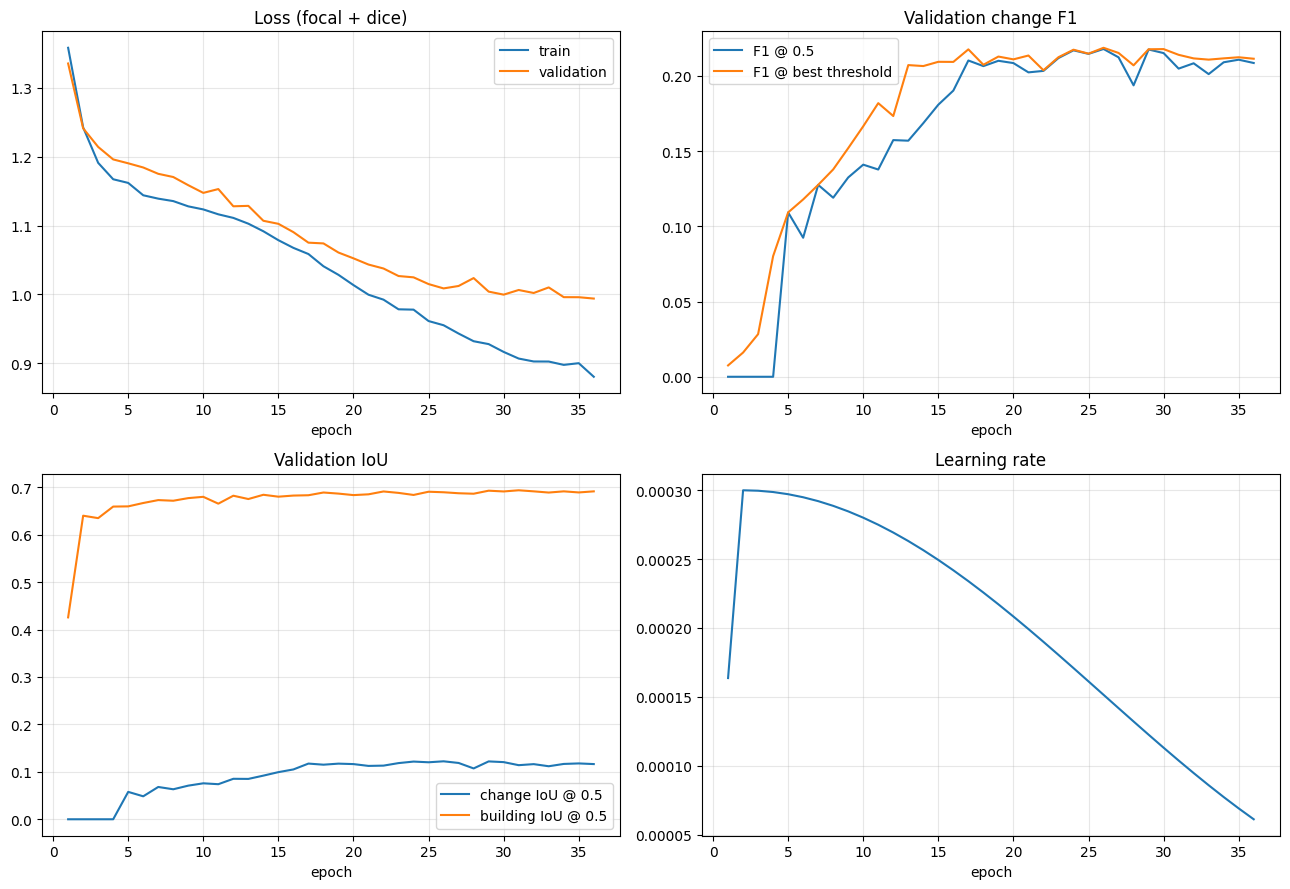

In [12]:
epochs = history["epoch"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(epochs, history["train_loss"], label="train")
axes[0, 0].plot(epochs, history["val_loss"], label="validation")
axes[0, 0].set_title(f"Loss (focal + {LOSS_REGION})")

axes[0, 1].plot(epochs, history["val_f1"], label="F1 @ 0.5")
axes[0, 1].plot(epochs, history["val_best_f1"], label="F1 @ best threshold")
axes[0, 1].set_title("Validation change F1")

axes[1, 0].plot(epochs, history["val_iou"], label="change IoU @ 0.5")
axes[1, 0].plot(epochs, history["val_building_iou"], label="building IoU @ 0.5")
axes[1, 0].set_title("Validation IoU")

axes[1, 1].plot(epochs, history["lr"])
axes[1, 1].set_title("Learning rate")

for ax in axes.flat:
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
    if ax.get_legend_handles_labels()[0]:
        ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150)
plt.show()

## Step 13: Evaluate the best model on the test set

This loads `best.pt` (the epoch with the best validation F1) and scores the **held-out test locations** at the **threshold chosen on validation**. The test set had no say in training, checkpoint choice, or threshold choice, so these are the numbers to report.

The table shows validation and test side by side:
- **Change detection:** precision, recall, F1, IoU.
- **Building segmentation:** IoU and F1 at 0.5 (auxiliary task).

Everything is saved to `training/test_metrics.json`.

> **Comparing with other work:** these are **pixel-level scores on a 128×128 grid** (~32 m cells), computed per consecutive month pair on SpaceNet-7's labeled training locations, **excluding cloud-masked pixels**. They are **not** the official SpaceNet-7 SCOT metric, which tracks individual buildings at full resolution. Don't put them in the same table as challenge leaderboard results.

In [13]:
best_state = torch.load(best_path, map_location=device, weights_only=False)
model.load_state_dict(best_state["model"])
threshold = best_state["threshold"]

results = {"run_name": RUN_NAME, "features": FEATURES_SUBDIR, "grid": GRID, "feature_dim": FEATURE_DIM,
           "model_variant": MODEL_VARIANT, "loss_region": LOSS_REGION,
           "best_epoch": best_state["epoch"], "epochs_trained": len(history["epoch"]), "threshold": threshold,
           "split_sizes": {k: len(v) for k, v in split.items()}}
for name in ["val", "test"]:
    loss, change_counts, building_counts = evaluate(split[name])
    building = building_counts.at(0.5)
    results[name] = {"loss": loss, "change": change_counts.at(threshold),
                     "building": {"iou": building["iou"], "f1": building["f1"]}}

(OUTPUT_DIR / "test_metrics.json").write_text(json.dumps(results, indent=2))

print(f"Run: {RUN_NAME} ({GRID}x{GRID} x {FEATURE_DIM}, model {MODEL_VARIANT}, loss focal+{LOSS_REGION})")
print(f"Best epoch: {results['best_epoch']} of {results['epochs_trained']} | threshold (chosen on validation): {threshold:.2f}\n")
print(f"{'':12s}{'Precision':>10s}{'Recall':>10s}{'F1':>10s}{'IoU':>10s}{'Bldg IoU':>10s}{'Bldg F1':>10s}")
for name in ["val", "test"]:
    c, b = results[name]["change"], results[name]["building"]
    print(f"{name + f' ({len(split[name])})':12s}{c['precision']:10.4f}{c['recall']:10.4f}{c['f1']:10.4f}{c['iou']:10.4f}"
          f"{b['iou']:10.4f}{b['f1']:10.4f}")
print(f"\nSaved to {OUTPUT_DIR / 'test_metrics.json'}")

Run: grid64_pca256 (64x64 x 256, model baseline, loss focal+dice)
Best epoch: 26 of 36 | threshold (chosen on validation): 0.65

             Precision    Recall        F1       IoU  Bldg IoU   Bldg F1
val (9)         0.1883    0.2605    0.2186    0.1227    0.6894    0.8162
test (9)        0.1994    0.1602    0.1776    0.0975    0.7044    0.8265

Saved to /content/drive/MyDrive/datasets/spacenet7_cache/training/grid64_pca256/test_metrics.json


## Step 14: Visualize predictions on test locations

For each of up to 3 test locations, this shows the **month pair with the most real change** (change outside cloud-masked areas):

| Before | After | Ground-truth change | Predicted probability | Prediction at threshold |
|---|---|---|---|---|

The before and after images are read from the raw GeoTIFFs on Drive at 512 px. In the last column, **green = correct detection, red = false alarm, blue = missed change, grey = ignored (cloud-masked in either month)**. The ground-truth column shows ignored areas in grey too.

The figure is saved to `training/test_predictions.png`.

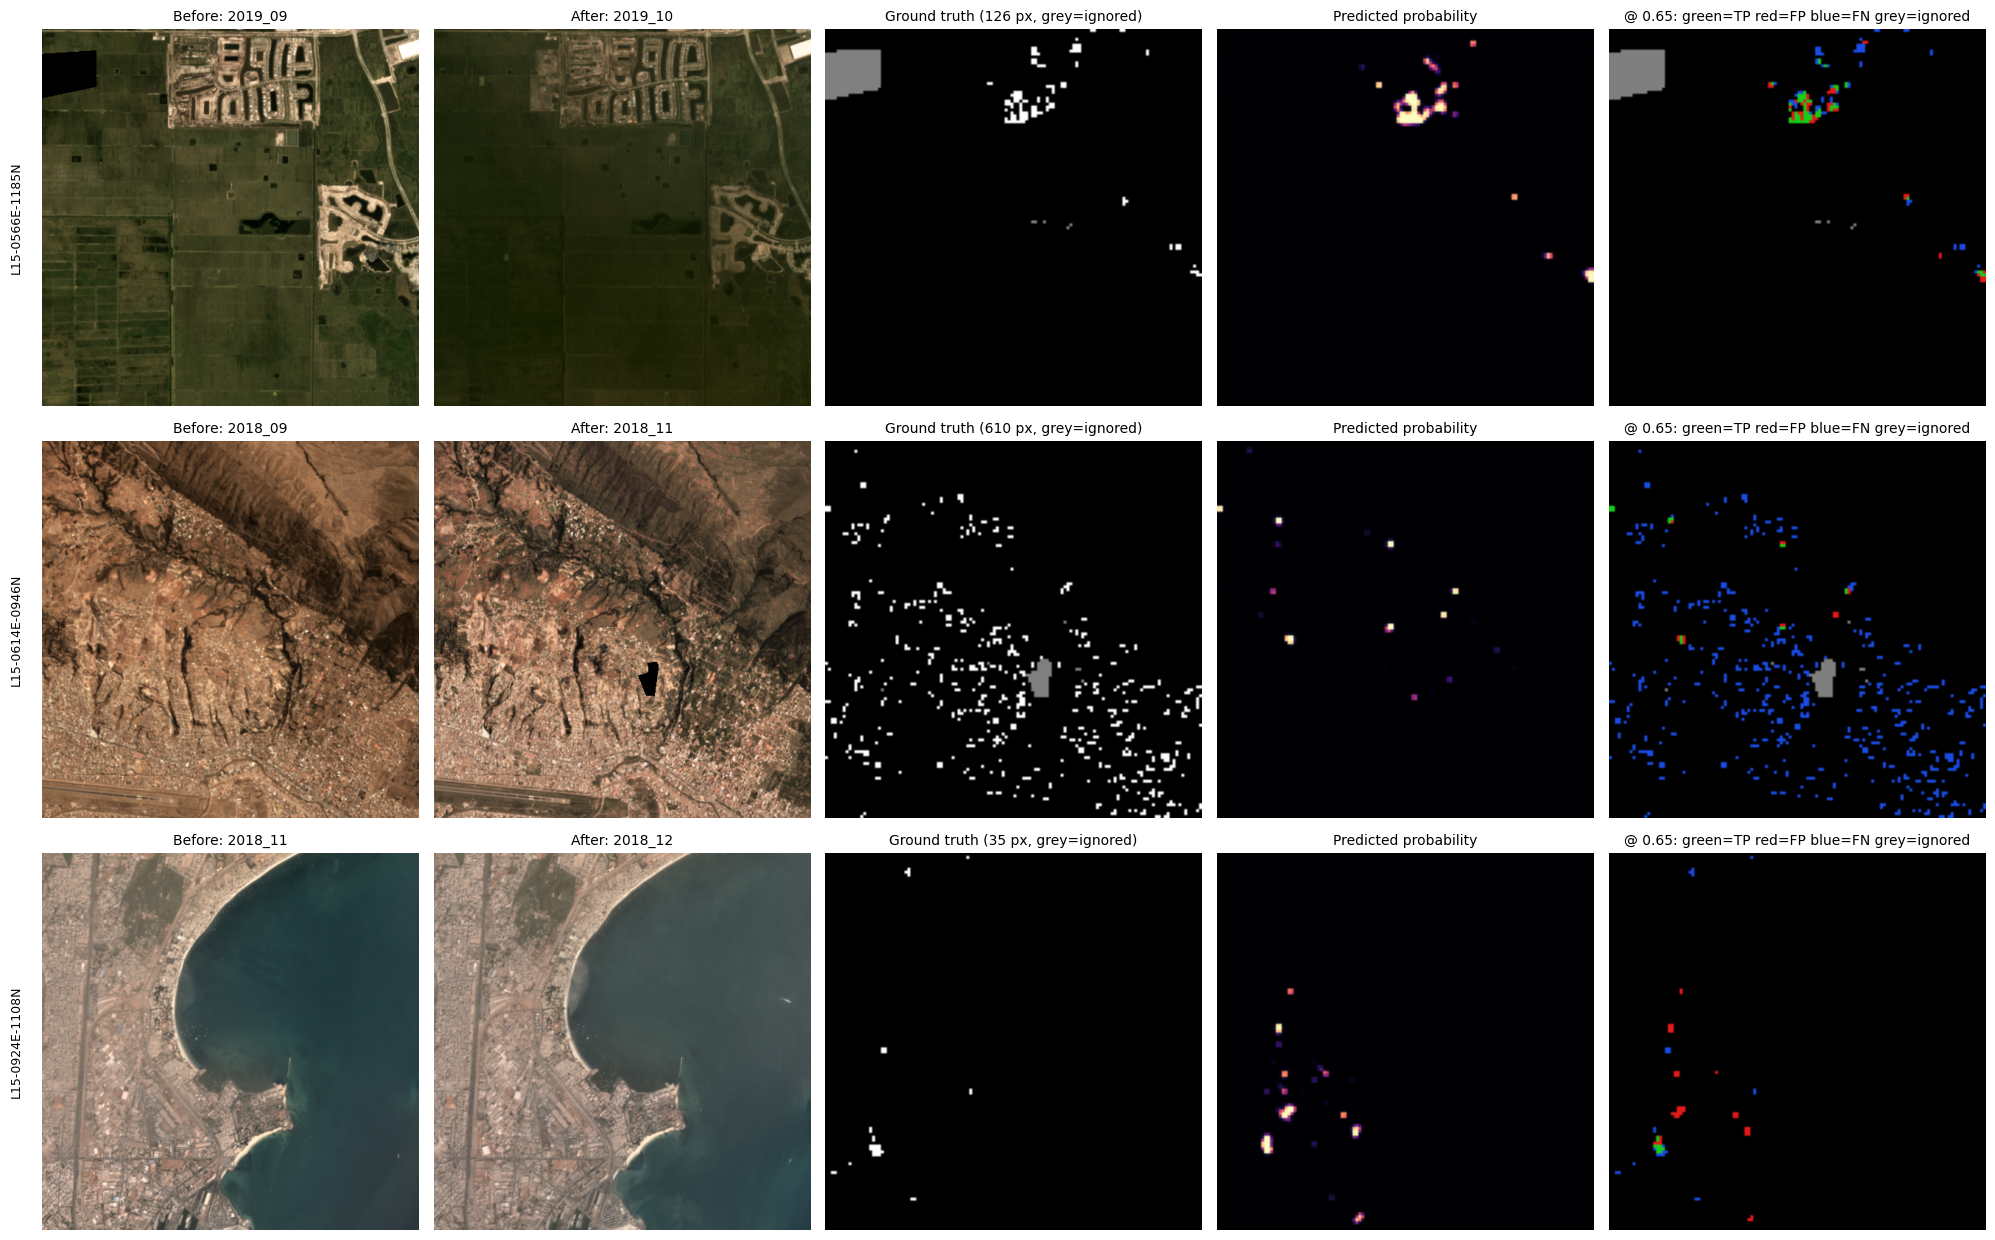

Saved to /content/drive/MyDrive/datasets/spacenet7_cache/training/grid64_pca256/test_predictions.png


In [14]:
def read_rgb(loc_id, month, size=512):
    folder = DATA_ROOT / loc_id / "images_masked"
    if not folder.exists():
        folder = DATA_ROOT / loc_id / "images"
    path = next(folder.glob(f"global_monthly_{month}_*.tif"))
    with rasterio.open(path) as src:
        img = src.read([1, 2, 3], out_shape=(3, size, size), resampling=Resampling.bilinear)
    return np.transpose(img, (1, 2, 0))


model.eval()
test_ids = split["test"][:3]
fig, axes = plt.subplots(len(test_ids), 5, figsize=(20, 4.2 * len(test_ids)), squeeze=False)

for row, loc_id in enumerate(test_ids):
    batch = make_batch([loc_id])
    with torch.no_grad(), torch.autocast(device.type, dtype=torch.float16, enabled=device.type == "cuda"):
        outputs = model(batch["features"], batch["month_offsets"], batch["valid"])
    probs = torch.sigmoid(outputs["change_logits"].float()).cpu()
    _, targets = compute_loss(outputs, batch)
    change, keep = targets["change"].cpu().bool(), targets["change_keep"].cpu()

    t = int((change & keep).flatten(1).sum(1).argmax())
    months = data[loc_id]["months"]
    target, kept, prob = (change[t] & keep[t]).numpy(), keep[t].numpy(), probs[t].numpy()
    predicted = (prob > threshold) & kept

    ground_truth = np.where(kept, target.astype(float), 0.5)
    overlay = np.zeros((*target.shape, 3))
    overlay[~kept] = [0.5, 0.5, 0.5]
    overlay[predicted & target] = [0.1, 0.8, 0.1]
    overlay[predicted & ~target] = [0.9, 0.1, 0.1]
    overlay[~predicted & target] = [0.1, 0.3, 0.9]

    panels = [(read_rgb(loc_id, months[t]), f"Before: {months[t]}"),
              (read_rgb(loc_id, months[t + 1]), f"After: {months[t + 1]}"),
              (ground_truth, f"Ground truth ({int(target.sum())} px, grey=ignored)"),
              (prob, "Predicted probability"),
              (overlay, f"@ {threshold:.2f}: green=TP red=FP blue=FN grey=ignored")]
    for col, (image, title) in enumerate(panels):
        ax = axes[row, col]
        ax.imshow(image, cmap="magma" if col == 3 else "gray", vmin=0, vmax=1 if col in (2, 3) else None)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    axes[row, 0].text(-0.05, 0.5, loc_id[:15], transform=axes[row, 0].transAxes, rotation=90,
                      va="center", ha="right", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "test_predictions.png", dpi=150)
plt.show()
print(f"Saved to {OUTPUT_DIR / 'test_predictions.png'}")

## Step 15: Compare every run

Each run keeps its own folder, so nothing is lost when you train another variant. This step finds every `test_metrics.json` under `training/` (skipping archived runs) and shows them together:
- **Table:** test precision, recall, F1, IoU and building IoU for each run, best first. The early run saved directly in `training/` (before run folders existed) is labelled `grid32`.
- **Plot:** validation change F1 per epoch for every run that has a `history.json`, so you can see how quickly each one learned and where it stopped.

Run this after any training run to see the new one next to the old ones. Part 4 adds the training-free baselines to the same table.

run                     model     loss           grid epoch   thr  val F1  test P  test R  test F1    IoU  bldg IoU
grid64_pca256           baseline  focal+dice       64    26  0.65   0.219   0.199   0.160    0.178  0.097     0.704
grid64_xattn_tversky    xattn     focal+tversky    64    25  0.95   0.215   0.170   0.183    0.176  0.096     0.679
grid32                  baseline  focal+dice        ?    21  0.85   0.156   0.151   0.125    0.137  0.073     0.623


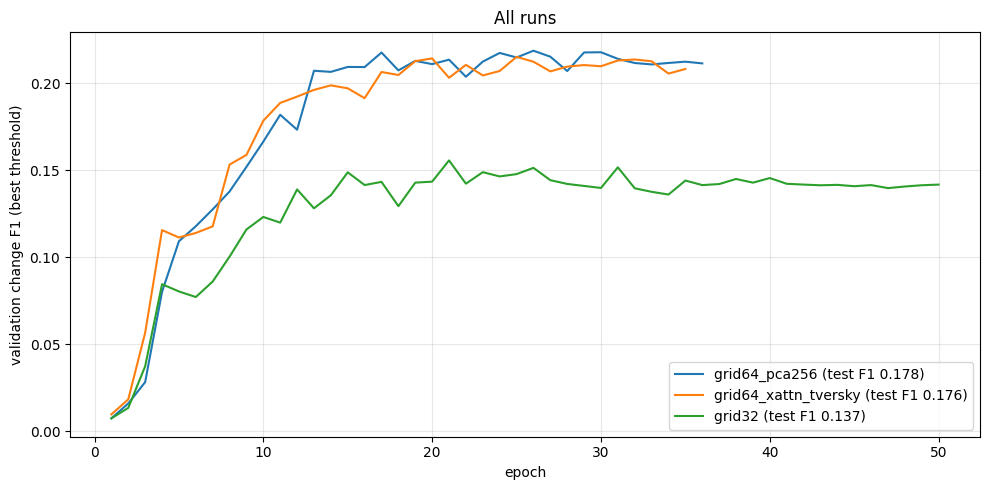

In [15]:
run_dirs = [p for p in TRAINING_DIR.glob("*/test_metrics.json") if not p.parent.name.startswith("archive_")]
if (TRAINING_DIR / "test_metrics.json").exists():
    run_dirs.append(TRAINING_DIR / "test_metrics.json")

runs = []
for metrics_path in run_dirs:
    m = json.loads(metrics_path.read_text())
    name = m.get("run_name", "grid32" if metrics_path.parent == TRAINING_DIR else metrics_path.parent.name)
    history_path = metrics_path.parent / "history.json"
    runs.append({"name": name, "model": m.get("model_variant", "baseline"), "loss": f"focal+{m.get('loss_region', 'dice')}",
                 "grid": m.get("grid", "?"), "best_epoch": m["best_epoch"], "threshold": m["threshold"],
                 "val_f1": m["val"]["change"]["f1"], **{f"test_{k}": v for k, v in m["test"]["change"].items() if k != "threshold"},
                 "building_iou": m["test"]["building"]["iou"],
                 "history": json.loads(history_path.read_text()) if history_path.exists() else None})
runs.sort(key=lambda r: -r["test_f1"])

print(f"{'run':24s}{'model':10s}{'loss':14s}{'grid':>5s}{'epoch':>6s}{'thr':>6s}{'val F1':>8s}{'test P':>8s}{'test R':>8s}{'test F1':>9s}{'IoU':>7s}{'bldg IoU':>10s}")
for r in runs:
    print(f"{r['name']:24s}{r['model']:10s}{r['loss']:14s}{str(r['grid']):>5s}{r['best_epoch']:>6d}{r['threshold']:>6.2f}{r['val_f1']:>8.3f}"
          f"{r['test_precision']:>8.3f}{r['test_recall']:>8.3f}{r['test_f1']:>9.3f}{r['test_iou']:>7.3f}{r['building_iou']:>10.3f}")

with_history = [r for r in runs if r["history"]]
if with_history:
    fig, ax = plt.subplots(figsize=(10, 5))
    for r in with_history:
        ax.plot(r["history"]["epoch"], r["history"]["val_best_f1"], label=f"{r['name']} (test F1 {r['test_f1']:.3f})")
    ax.set_xlabel("epoch")
    ax.set_ylabel("validation change F1 (best threshold)")
    ax.set_title("All runs")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(TRAINING_DIR / "all_runs_val_f1.png", dpi=150)
    plt.show()